# 06 - Preparación y etiquetado del dataset SWaT A6 Dec 2019

Este notebook prepara el dataset **SWaT A6 OTDataset Dec 2019** para la validación externa supervisada.

## Entradas esperadas

```text
data/raw/SWaT.A6_OTDataset_Dec_19/Dec2019.xlsx
data/raw/SWaT.A6_OTDataset_Dec_19/etiquetado_dataset_A6.csv
```

También se permite que `etiquetado_dataset_A6.csv` esté en:

```text
data/clean/SWaT.A6_OTDataset_Dec_19/etiquetado_dataset_A6.csv
```

## Formatos aceptados para el archivo de etiquetado

El notebook soporta dos formatos:

### Formato A
```text
Periodo, Label, Status
10:05 - 12:29, Normal, 0
12:30 - 12:33, Ataque, 1
```

### Formato B
```text
start_time, end_time, attack_name, attack_id
10:05, 12:29, Normal, 0
12:30, 12:33, Disrupt Sensor and Actuator, 1
```

En ambos casos, solo se etiqueta como ataque cuando el campo de estado/ID es `1`.


## 1. Imports y rutas

In [1]:
from pathlib import Path
import json
import re

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 120)
pd.set_option("display.max_colwidth", 180)


In [2]:
current_dir = Path.cwd()

if (current_dir / "data").exists():
    PROJECT_ROOT = current_dir
else:
    PROJECT_ROOT = current_dir.parent

RAW_DIR = PROJECT_ROOT / "data" / "raw" / "SWaT.A6_OTDataset_Dec_19"
CLEAN_DIR = PROJECT_ROOT / "data" / "clean" / "SWaT.A6_OTDataset_Dec_19"
CLEAN_DIR.mkdir(parents=True, exist_ok=True)

RAW_DATA_PATH = RAW_DIR / "Dec2019.xlsx"

ATTACK_SCHEDULE_PATH = RAW_DIR / "etiquetado_dataset_A6.csv"

if not ATTACK_SCHEDULE_PATH.exists():
    fallback_path = CLEAN_DIR / "etiquetado_dataset_A6.csv"
    if fallback_path.exists():
        ATTACK_SCHEDULE_PATH = fallback_path

LABELED_OUTPUT_PATH = CLEAN_DIR / "Dec2019_labeled.csv"
SCHEDULE_OUTPUT_PATH = CLEAN_DIR / "etiquetado_dataset_A6_parsed.csv"
METADATA_OUTPUT_PATH = CLEAN_DIR / "labeling_metadata.json"

print("PROJECT_ROOT:", PROJECT_ROOT)
print("RAW_DATA_PATH:", RAW_DATA_PATH)
print("ATTACK_SCHEDULE_PATH:", ATTACK_SCHEDULE_PATH)
print("CLEAN_DIR:", CLEAN_DIR)


PROJECT_ROOT: d:\Documentos\Uniandes\12 Semestre\PROYECTO DE GRADO\repoPrincipal\ics-synthetic-data-augmentation
RAW_DATA_PATH: d:\Documentos\Uniandes\12 Semestre\PROYECTO DE GRADO\repoPrincipal\ics-synthetic-data-augmentation\data\raw\SWaT.A6_OTDataset_Dec_19\Dec2019.xlsx
ATTACK_SCHEDULE_PATH: d:\Documentos\Uniandes\12 Semestre\PROYECTO DE GRADO\repoPrincipal\ics-synthetic-data-augmentation\data\raw\SWaT.A6_OTDataset_Dec_19\etiquetado_dataset_A6.csv
CLEAN_DIR: d:\Documentos\Uniandes\12 Semestre\PROYECTO DE GRADO\repoPrincipal\ics-synthetic-data-augmentation\data\clean\SWaT.A6_OTDataset_Dec_19


In [3]:
required_paths = [RAW_DATA_PATH, ATTACK_SCHEDULE_PATH]
missing_paths = [str(p) for p in required_paths if not p.exists()]

if missing_paths:
    raise FileNotFoundError(
        "Faltan archivos requeridos:\n" + "\n".join(missing_paths)
    )

print("Archivos encontrados correctamente.")


Archivos encontrados correctamente.


## 2. Cargar dataset Excel y archivo de periodos

In [4]:
excel_file = pd.ExcelFile(RAW_DATA_PATH)
print("Hojas disponibles:", excel_file.sheet_names)

sheet_name = "Dec2019" if "Dec2019" in excel_file.sheet_names else excel_file.sheet_names[0]

df = pd.read_excel(RAW_DATA_PATH, sheet_name=sheet_name)
schedule = pd.read_csv(ATTACK_SCHEDULE_PATH)

# Limpiar nombres de columnas del CSV de etiquetado
schedule.columns = [str(c).strip() for c in schedule.columns]

print("Dataset shape:", df.shape)
print("Schedule shape:", schedule.shape)
print("Schedule columns:", schedule.columns.tolist())

display(df.head())
display(schedule)


Hojas disponibles: ['Dec2019']
Dataset shape: (13201, 82)
Schedule shape: (11, 4)
Schedule columns: ['start_time', 'end_time', 'attack_name', 'attack_id']


,t_stamp,P1_STATE,LIT101.Pv,FIT101.Pv,MV101.Status,P101.Status,P102.Status,P2_STATE,FIT201.Pv,AIT201.Pv,AIT202.Pv,AIT203.Pv,MV201.Status,P201.Status,P202.Status,P203.Status,P204.Status,P205.Status,P206.Status,P207.Status,P208.Status,LS201.Alarm,LS202.Alarm,LSL203.Alarm,LSLL203.Alarm,P3_STATE,AIT301.Pv,AIT302.Pv,AIT303.Pv,LIT301.Pv,FIT301.Pv,DPIT301.Pv,MV301.Status,MV302.Status,MV303.Status,MV304.Status,P301.Status,P302.Status,PSH301.Alarm,DPSH301.Alarm,P4_STATE,LIT401.Pv,FIT401.Pv,AIT401.Pv,AIT402.Pv,P401.Status,P402.Status,P403.Status,P404.Status,UV401.Status,LS401.Alarm,P5_STATE,FIT501.Pv,FIT502.Pv,FIT503.Pv,FIT504.Pv,AIT501.Pv,AIT502.Pv,AIT503.Pv,AIT504.Pv,PIT501.Pv,PIT502.Pv,PIT503.Pv,P501.Status,P502.Status,MV501.Status,MV502.Status,MV503.Status,MV504.Status,PSH501.Alarm,PSL501.Alarm,P6_STATE,FIT601.Pv,P601.Status,P602.Status,P603.Status,LSH601.Alarm,LSL601.Alarm,LSH602.Alarm,LSL602.Alarm,LSH603.Alarm,LSL603.Alarm
0,2019-12-06 10:05:00,3,658.661255,0.0,1,2.0,1,2,2.313523,35.21533,8.205781,133.350418,2,2,1,2,1,1,1,1,1,Inactive,Inactive,Inactive,Inactive,7,6.792944,155.579742,35.149494,895.123047,1.849278,14.415135,1,2,1,1,2,1,Inactive,Inactive,4,793.911800,1.355785,0,195.078186,2,1,2,1,2,Inactive,12,1.356960,1.214423,0.113049,0,7.022430,190.0282,29.223276,0.615227,221.3535,3.380002,194.068832,2,1,2,2,1,1,Inactive,Inactive,2,0.000256,2,1,1,Inactive,Inactive,Active,Inactive,Inactive,Active
1,2019-12-06 10:05:01,3,659.171600,0.0,1,2.0,1,2,2.311857,35.21533,8.205781,133.401688,2,2,1,2,1,1,1,1,1,Inactive,Inactive,Inactive,Inactive,7,6.793777,155.579742,35.245533,895.123047,1.846972,14.415135,1,2,1,1,2,1,Inactive,Inactive,4,793.565735,1.355785,0,195.078186,2,1,2,1,2,Inactive,12,1.356960,1.214935,0.113305,0,7.026276,190.0282,29.223276,0.615227,221.3535,3.380002,194.148941,2,1,2,2,1,1,Inactive,Inactive,2,0.000256,2,1,1,Inactive,Inactive,Active,Inactive,Inactive,Active
2,2019-12-06 10:05:02,3,659.681800,0.0,1,2.0,1,2,2.311601,35.21533,8.208344,133.606766,2,2,1,2,1,1,1,1,1,Inactive,Inactive,Inactive,Inactive,7,6.795025,155.579742,35.245533,895.123047,1.846972,14.415135,1,2,1,1,2,1,Inactive,Inactive,4,793.796448,1.355785,0,195.078186,2,1,2,1,2,Inactive,12,1.356960,1.207762,0.113305,0,7.031082,190.0282,29.223276,0.615227,221.3535,3.380002,194.213028,2,1,2,2,1,1,Inactive,Inactive,2,0.000256,2,1,1,Inactive,Inactive,Active,Inactive,Inactive,Active
3,2019-12-06 10:05:03,3,660.349100,0.0,1,2.0,1,2,2.310448,35.21533,8.209626,133.606766,2,2,1,2,1,1,1,1,1,Inactive,Inactive,Inactive,Inactive,7,6.803349,155.579742,35.245533,895.363400,1.846972,14.415135,1,2,1,1,2,1,Inactive,Inactive,4,793.565735,1.357577,0,195.078186,2,1,2,1,2,Inactive,12,1.356960,1.204560,0.113305,0,7.031082,190.0282,29.223276,0.615227,221.3535,3.380002,194.213028,2,1,2,2,1,1,Inactive,Inactive,2,0.000256,2,1,1,Inactive,Inactive,Active,Inactive,Inactive,Active
4,2019-12-06 10:05:04,3,660.780945,0.0,1,2.0,1,2,2.310448,35.21533,8.209626,133.606766,2,2,1,2,1,1,1,1,1,Inactive,Inactive,Inactive,Inactive,7,6.808759,155.579742,35.245533,895.363400,1.849662,14.415135,1,2,1,1,2,1,Inactive,Inactive,4,793.527300,1.357577,0,195.078186,2,1,2,1,2,Inactive,12,1.357857,1.204560,0.113305,0,7.037490,190.0282,29.223276,0.884389,221.3535,3.380002,194.213028,2,1,2,2,1,1,Inactive,Inactive,2,0.000256,2,1,1,Inactive,Inactive,Active,Inactive,Inactive,Active


,start_time,end_time,attack_name,attack_id
0,10:05,12:29,Normal / Exfiltration,0
1,12:30,12:33,Disrupt Sensor and Actuator (Burst 1),1
2,12:33,12:43,Normal (sleep),0
3,12:43,12:46,Disrupt Sensor and Actuator (Burst 2),1
4,12:46,12:56,Normal,0
5,12:56,12:59,Disrupt Sensor and Actuator (Burst 3),1
6,12:59,13:09,Normal,0
7,13:09,13:12,Disrupt Sensor and Actuator (Burst 4),1
8,13:12,13:22,Normal,0
9,13:22,13:25,Disrupt Sensor and Actuator (Burst 5),1


## 3. Parsear timestamps del dataset

In [5]:
if "t_stamp" not in df.columns:
    candidates = [c for c in df.columns if "time" in str(c).lower()]
    if not candidates:
        raise ValueError("No se encontró columna t_stamp ni una columna de tiempo alternativa.")
    time_col = candidates[0]
    print("Usando columna de tiempo alternativa:", time_col)
    df = df.rename(columns={time_col: "t_stamp"})

df = df.copy()
df["t_stamp"] = pd.to_datetime(df["t_stamp"], errors="coerce")

invalid_ts = int(df["t_stamp"].isna().sum())
print("Timestamps inválidos:", invalid_ts)

if invalid_ts > 0:
    display(df[df["t_stamp"].isna()].head())
    raise ValueError("Existen timestamps inválidos en Dec2019.xlsx.")

df = df.sort_values("t_stamp").reset_index(drop=True)

dataset_date = df["t_stamp"].dt.date.min()

print("Fecha del dataset:", dataset_date)
print("Inicio:", df["t_stamp"].min())
print("Fin:", df["t_stamp"].max())
print("Filas:", len(df))
print("Timestamps duplicados:", int(df["t_stamp"].duplicated().sum()))


Timestamps inválidos: 0
Fecha del dataset: 2019-12-06
Inicio: 2019-12-06 10:05:00
Fin: 2019-12-06 13:45:00
Filas: 13201
Timestamps duplicados: 0


In [6]:
time_diffs = df["t_stamp"].diff().dropna()

sampling_summary = (
    time_diffs.value_counts()
    .head(10)
    .rename_axis("time_delta")
    .reset_index(name="count")
)

display(sampling_summary)

if len(sampling_summary) > 0:
    print("Intervalo de muestreo más común:", sampling_summary.iloc[0]["time_delta"])


,time_delta,count
0,0 days 00:00:01,13200


Intervalo de muestreo más común: 0 days 00:00:01


## 4. Normalizar archivo de etiquetado A6

In [7]:
# Esta celda acepta dos esquemas:
# A) Periodo, Label, Status
# B) start_time, end_time, attack_name, attack_id

def normalize_colname(c):
    return str(c).strip().lower().replace(" ", "_")

original_schedule_cols = schedule.columns.tolist()
schedule_norm = schedule.copy()
schedule_norm.columns = [normalize_colname(c) for c in schedule_norm.columns]

print("Columnas originales:", original_schedule_cols)
print("Columnas normalizadas:", schedule_norm.columns.tolist())

has_period_schema = {"periodo", "label", "status"}.issubset(set(schedule_norm.columns))
has_start_end_schema = {"start_time", "end_time", "attack_name", "attack_id"}.issubset(set(schedule_norm.columns))

if not has_period_schema and not has_start_end_schema:
    raise ValueError(
        "No se reconoce la estructura del CSV de etiquetado. "
        "Debe tener columnas ['Periodo','Label','Status'] o "
        "['start_time','end_time','attack_name','attack_id']. "
        f"Columnas encontradas: {original_schedule_cols}"
    )

def split_period(period_text):
    text = str(period_text).strip()
    parts = re.split(r"\s*-\s*", text)
    if len(parts) != 2:
        raise ValueError(f"No se pudo parsear el periodo: {period_text}")
    return parts[0].strip(), parts[1].strip()

if has_period_schema:
    print("Esquema detectado: Periodo / Label / Status")

    schedule_work = schedule_norm[["periodo", "label", "status"]].copy()
    schedule_work[["start_time_raw", "end_time_raw"]] = schedule_work["periodo"].apply(
        lambda x: pd.Series(split_period(x))
    )
    schedule_work = schedule_work.rename(columns={
        "label": "attack_name",
        "status": "attack_id"
    })

elif has_start_end_schema:
    print("Esquema detectado: start_time / end_time / attack_name / attack_id")

    schedule_work = schedule_norm[["start_time", "end_time", "attack_name", "attack_id"]].copy()
    schedule_work["start_time_raw"] = schedule_work["start_time"].astype(str).str.strip()
    schedule_work["end_time_raw"] = schedule_work["end_time"].astype(str).str.strip()

schedule_work["attack_id"] = pd.to_numeric(schedule_work["attack_id"], errors="coerce").astype("Int64")

if schedule_work["attack_id"].isna().any():
    display(schedule_work[schedule_work["attack_id"].isna()])
    raise ValueError("Hay valores no numéricos en attack_id/status.")

if not set(schedule_work["attack_id"].dropna().unique()).issubset({0, 1}):
    display(schedule_work)
    raise ValueError("attack_id/status solo debe contener 0 o 1.")

display(schedule_work)


Columnas originales: ['start_time', 'end_time', 'attack_name', 'attack_id']
Columnas normalizadas: ['start_time', 'end_time', 'attack_name', 'attack_id']
Esquema detectado: start_time / end_time / attack_name / attack_id


,start_time,end_time,attack_name,attack_id,start_time_raw,end_time_raw
0,10:05,12:29,Normal / Exfiltration,0,10:05,12:29
1,12:30,12:33,Disrupt Sensor and Actuator (Burst 1),1,12:30,12:33
2,12:33,12:43,Normal (sleep),0,12:33,12:43
3,12:43,12:46,Disrupt Sensor and Actuator (Burst 2),1,12:43,12:46
4,12:46,12:56,Normal,0,12:46,12:56
5,12:56,12:59,Disrupt Sensor and Actuator (Burst 3),1,12:56,12:59
6,12:59,13:09,Normal,0,12:59,13:09
7,13:09,13:12,Disrupt Sensor and Actuator (Burst 4),1,13:09,13:12
8,13:12,13:22,Normal,0,13:12,13:22
9,13:22,13:25,Disrupt Sensor and Actuator (Burst 5),1,13:22,13:25


## 5. Convertir periodos a datetimes

In [8]:
def parse_time_on_dataset_date(time_text, dataset_date):
    # El CSV viene en formato 24h HH:MM. También tolera HH:MM:SS.
    txt = str(time_text).strip()
    full_text = f"{dataset_date} {txt}"

    parsed = pd.to_datetime(full_text, format="%Y-%m-%d %H:%M", errors="coerce")
    if pd.isna(parsed):
        parsed = pd.to_datetime(full_text, format="%Y-%m-%d %H:%M:%S", errors="coerce")
    if pd.isna(parsed):
        parsed = pd.to_datetime(full_text, errors="coerce")

    return parsed

schedule_parsed = schedule_work.copy()

schedule_parsed["start_datetime"] = schedule_parsed["start_time_raw"].apply(
    lambda x: parse_time_on_dataset_date(x, dataset_date)
)

schedule_parsed["end_datetime"] = schedule_parsed["end_time_raw"].apply(
    lambda x: parse_time_on_dataset_date(x, dataset_date)
)

invalid_intervals = schedule_parsed[
    schedule_parsed["start_datetime"].isna() |
    schedule_parsed["end_datetime"].isna()
]

if len(invalid_intervals) > 0:
    display(invalid_intervals)
    raise ValueError("Algunos periodos no pudieron convertirse a datetime.")

schedule_parsed["duration_seconds"] = (
    schedule_parsed["end_datetime"] - schedule_parsed["start_datetime"]
).dt.total_seconds().astype(int)

schedule_parsed["attack_label_interval"] = schedule_parsed["attack_id"].astype(int)
schedule_parsed["attack_name_interval"] = np.where(
    schedule_parsed["attack_id"].astype(int) == 1,
    schedule_parsed["attack_name"].astype(str),
    "normal"
)

display(schedule_parsed)


,start_time,end_time,attack_name,attack_id,start_time_raw,end_time_raw,start_datetime,end_datetime,duration_seconds,attack_label_interval,attack_name_interval
0,10:05,12:29,Normal / Exfiltration,0,10:05,12:29,2019-12-06 10:05:00,2019-12-06 12:29:00,8640,0,normal
1,12:30,12:33,Disrupt Sensor and Actuator (Burst 1),1,12:30,12:33,2019-12-06 12:30:00,2019-12-06 12:33:00,180,1,Disrupt Sensor and Actuator (Burst 1)
2,12:33,12:43,Normal (sleep),0,12:33,12:43,2019-12-06 12:33:00,2019-12-06 12:43:00,600,0,normal
3,12:43,12:46,Disrupt Sensor and Actuator (Burst 2),1,12:43,12:46,2019-12-06 12:43:00,2019-12-06 12:46:00,180,1,Disrupt Sensor and Actuator (Burst 2)
4,12:46,12:56,Normal,0,12:46,12:56,2019-12-06 12:46:00,2019-12-06 12:56:00,600,0,normal
5,12:56,12:59,Disrupt Sensor and Actuator (Burst 3),1,12:56,12:59,2019-12-06 12:56:00,2019-12-06 12:59:00,180,1,Disrupt Sensor and Actuator (Burst 3)
6,12:59,13:09,Normal,0,12:59,13:09,2019-12-06 12:59:00,2019-12-06 13:09:00,600,0,normal
7,13:09,13:12,Disrupt Sensor and Actuator (Burst 4),1,13:09,13:12,2019-12-06 13:09:00,2019-12-06 13:12:00,180,1,Disrupt Sensor and Actuator (Burst 4)
8,13:12,13:22,Normal,0,13:12,13:22,2019-12-06 13:12:00,2019-12-06 13:22:00,600,0,normal
9,13:22,13:25,Disrupt Sensor and Actuator (Burst 5),1,13:22,13:25,2019-12-06 13:22:00,2019-12-06 13:25:00,180,1,Disrupt Sensor and Actuator (Burst 5)


## 6. Validar consistencia de intervalos

In [9]:
if (schedule_parsed["duration_seconds"] <= 0).any():
    display(schedule_parsed[schedule_parsed["duration_seconds"] <= 0])
    raise ValueError("Hay intervalos con duración no positiva.")

data_start = df["t_stamp"].min()
data_end = df["t_stamp"].max()

outside_range = schedule_parsed[
    (schedule_parsed["start_datetime"] < data_start) |
    (schedule_parsed["end_datetime"] > data_end + pd.Timedelta(seconds=1))
]

print("Intervalos fuera del rango del dataset:", len(outside_range))
if len(outside_range) > 0:
    display(outside_range)

schedule_sorted = schedule_parsed.sort_values("start_datetime").reset_index(drop=True)

overlaps = []
gaps = []

for i in range(1, len(schedule_sorted)):
    prev_end = schedule_sorted.loc[i - 1, "end_datetime"]
    curr_start = schedule_sorted.loc[i, "start_datetime"]

    if curr_start < prev_end:
        overlaps.append({
            "previous_row": i - 1,
            "current_row": i,
            "previous_end": prev_end,
            "current_start": curr_start,
        })

    if curr_start > prev_end:
        gaps.append({
            "previous_row": i - 1,
            "current_row": i,
            "previous_end": prev_end,
            "current_start": curr_start,
            "gap_seconds": (curr_start - prev_end).total_seconds(),
        })

print("Solapamientos estrictos:", len(overlaps))
print("Gaps entre intervalos:", len(gaps))

if overlaps:
    display(pd.DataFrame(overlaps))

if gaps:
    display(pd.DataFrame(gaps))


Intervalos fuera del rango del dataset: 0
Solapamientos estrictos: 0
Gaps entre intervalos: 1


,previous_row,current_row,previous_end,current_start,gap_seconds
0,0,1,2019-12-06 12:29:00,2019-12-06 12:30:00,60.0


## 7. Etiquetar filas

In [10]:
df_labeled = df.copy()

df_labeled["attack_label"] = 0
df_labeled["attack_id"] = 0
df_labeled["attack_name"] = "normal"
df_labeled["attack_start_time"] = pd.NaT
df_labeled["attack_end_time"] = pd.NaT

matched_rows = []

for _, row in schedule_parsed.iterrows():
    start = row["start_datetime"]
    end = row["end_datetime"]
    status = int(row["attack_id"])

    # Intervalo semiabierto: start <= t_stamp < end
    mask = (df_labeled["t_stamp"] >= start) & (df_labeled["t_stamp"] < end)

    n_rows = int(mask.sum())

    if status == 1:
        df_labeled.loc[mask, "attack_label"] = 1
        df_labeled.loc[mask, "attack_id"] = 1
        df_labeled.loc[mask, "attack_name"] = row["attack_name"]
        df_labeled.loc[mask, "attack_start_time"] = start
        df_labeled.loc[mask, "attack_end_time"] = end

    matched_rows.append({
        "start_time": row["start_time_raw"],
        "end_time": row["end_time_raw"],
        "attack_name": row["attack_name"],
        "attack_id": status,
        "start_datetime": start,
        "end_datetime": end,
        "duration_seconds": int(row["duration_seconds"]),
        "matched_rows": n_rows,
    })

matched_rows_df = pd.DataFrame(matched_rows)
display(matched_rows_df)


,start_time,end_time,attack_name,attack_id,start_datetime,end_datetime,duration_seconds,matched_rows
0,10:05,12:29,Normal / Exfiltration,0,2019-12-06 10:05:00,2019-12-06 12:29:00,8640,8640
1,12:30,12:33,Disrupt Sensor and Actuator (Burst 1),1,2019-12-06 12:30:00,2019-12-06 12:33:00,180,180
2,12:33,12:43,Normal (sleep),0,2019-12-06 12:33:00,2019-12-06 12:43:00,600,600
3,12:43,12:46,Disrupt Sensor and Actuator (Burst 2),1,2019-12-06 12:43:00,2019-12-06 12:46:00,180,180
4,12:46,12:56,Normal,0,2019-12-06 12:46:00,2019-12-06 12:56:00,600,600
5,12:56,12:59,Disrupt Sensor and Actuator (Burst 3),1,2019-12-06 12:56:00,2019-12-06 12:59:00,180,180
6,12:59,13:09,Normal,0,2019-12-06 12:59:00,2019-12-06 13:09:00,600,600
7,13:09,13:12,Disrupt Sensor and Actuator (Burst 4),1,2019-12-06 13:09:00,2019-12-06 13:12:00,180,180
8,13:12,13:22,Normal,0,2019-12-06 13:12:00,2019-12-06 13:22:00,600,600
9,13:22,13:25,Disrupt Sensor and Actuator (Burst 5),1,2019-12-06 13:22:00,2019-12-06 13:25:00,180,180


## 8. Verificar conteos de etiqueta

In [11]:
label_counts = (
    df_labeled["attack_label"]
    .value_counts()
    .rename_axis("attack_label")
    .reset_index(name="rows")
)

display(label_counts)

total_rows = len(df_labeled)
attack_rows = int((df_labeled["attack_label"] == 1).sum())
normal_rows = int((df_labeled["attack_label"] == 0).sum())

print("Total rows:", total_rows)
print("Normal rows:", normal_rows, f"({normal_rows / total_rows:.2%})")
print("Attack rows:", attack_rows, f"({attack_rows / total_rows:.2%})")

expected_attack_seconds = int(schedule_parsed.loc[schedule_parsed["attack_id"] == 1, "duration_seconds"].sum())
print("Duración esperada de ataques físicos (segundos):", expected_attack_seconds)
print("Filas etiquetadas como ataque:", attack_rows)


,attack_label,rows
0,0,12301
1,1,900


Total rows: 13201
Normal rows: 12301 (93.18%)
Attack rows: 900 (6.82%)
Duración esperada de ataques físicos (segundos): 900
Filas etiquetadas como ataque: 900


In [12]:
attack_period_counts = (
    df_labeled[df_labeled["attack_label"] == 1]
    .groupby(["attack_name", "attack_start_time", "attack_end_time"], dropna=False)
    .size()
    .reset_index(name="rows")
)

display(attack_period_counts)


,attack_name,attack_start_time,attack_end_time,rows
0,Disrupt Sensor and Actuator (Burst 1),2019-12-06 12:30:00,2019-12-06 12:33:00,180
1,Disrupt Sensor and Actuator (Burst 2),2019-12-06 12:43:00,2019-12-06 12:46:00,180
2,Disrupt Sensor and Actuator (Burst 3),2019-12-06 12:56:00,2019-12-06 12:59:00,180
3,Disrupt Sensor and Actuator (Burst 4),2019-12-06 13:09:00,2019-12-06 13:12:00,180
4,Disrupt Sensor and Actuator (Burst 5),2019-12-06 13:22:00,2019-12-06 13:25:00,180


## 9. Visualizar etiquetas

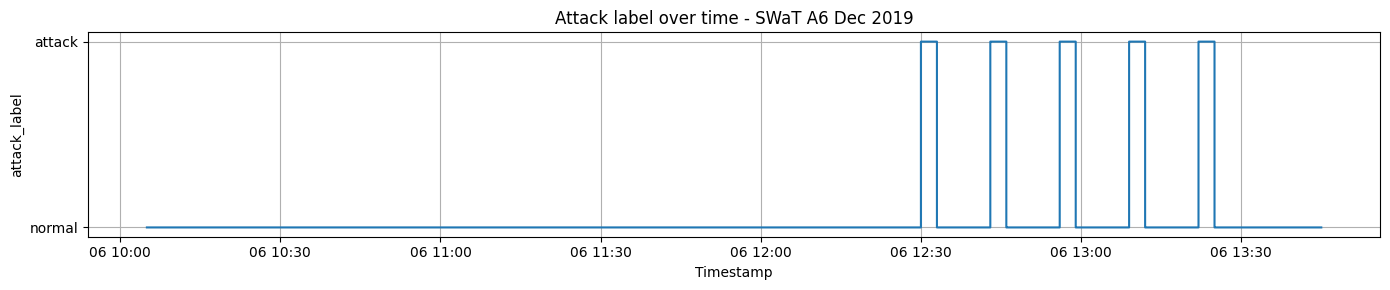

In [13]:
plt.figure(figsize=(14, 3))
plt.plot(df_labeled["t_stamp"], df_labeled["attack_label"], drawstyle="steps-post")
plt.title("Attack label over time - SWaT A6 Dec 2019")
plt.xlabel("Timestamp")
plt.ylabel("attack_label")
plt.yticks([0, 1], ["normal", "attack"])
plt.grid(True)
plt.tight_layout()
plt.show()


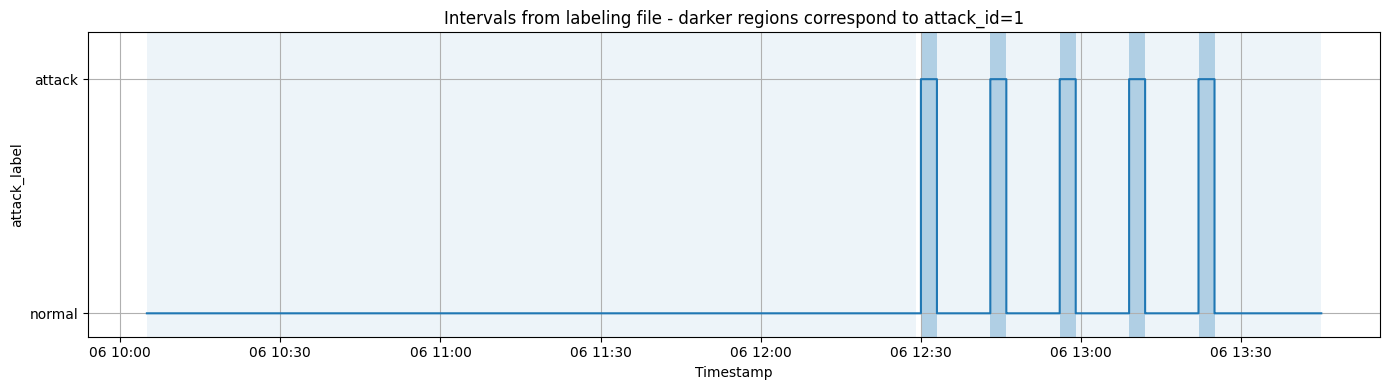

In [14]:
plt.figure(figsize=(14, 4))

for _, row in schedule_parsed.iterrows():
    color_alpha = 0.35 if int(row["attack_id"]) == 1 else 0.08
    plt.axvspan(row["start_datetime"], row["end_datetime"], alpha=color_alpha)

plt.plot(df_labeled["t_stamp"], df_labeled["attack_label"], drawstyle="steps-post")
plt.title("Intervals from labeling file - darker regions correspond to attack_id=1")
plt.xlabel("Timestamp")
plt.ylabel("attack_label")
plt.yticks([0, 1], ["normal", "attack"])
plt.ylim(-0.1, 1.2)
plt.grid(True)
plt.tight_layout()
plt.show()


## 10. Chequeo preliminar de columnas

In [15]:
print("Número de columnas totales:", len(df_labeled.columns))
print("Primeras columnas:")
print(df_labeled.columns[:20].tolist())

label_cols = ["attack_label", "attack_id", "attack_name", "attack_start_time", "attack_end_time"]
print("\nColumnas de etiqueta agregadas:")
print(label_cols)

display(df_labeled[["t_stamp"] + label_cols].head())


Número de columnas totales: 87
Primeras columnas:
['t_stamp', 'P1_STATE', 'LIT101.Pv', 'FIT101.Pv', 'MV101.Status', 'P101.Status', 'P102.Status', 'P2_STATE', 'FIT201.Pv', 'AIT201.Pv', 'AIT202.Pv', 'AIT203.Pv', 'MV201.Status', 'P201.Status', 'P202.Status', 'P203.Status', 'P204.Status', 'P205.Status', 'P206.Status', 'P207.Status']

Columnas de etiqueta agregadas:
['attack_label', 'attack_id', 'attack_name', 'attack_start_time', 'attack_end_time']


,t_stamp,attack_label,attack_id,attack_name,attack_start_time,attack_end_time
0,2019-12-06 10:05:00,0,0,normal,NaT,NaT
1,2019-12-06 10:05:01,0,0,normal,NaT,NaT
2,2019-12-06 10:05:02,0,0,normal,NaT,NaT
3,2019-12-06 10:05:03,0,0,normal,NaT,NaT
4,2019-12-06 10:05:04,0,0,normal,NaT,NaT


## 11. Guardar dataset etiquetado y metadata

In [16]:
df_labeled.to_csv(LABELED_OUTPUT_PATH, index=False)
schedule_parsed.to_csv(SCHEDULE_OUTPUT_PATH, index=False)

metadata = {
    "raw_data_path": str(RAW_DATA_PATH),
    "attack_schedule_path": str(ATTACK_SCHEDULE_PATH),
    "labeled_output_path": str(LABELED_OUTPUT_PATH),
    "schedule_output_path": str(SCHEDULE_OUTPUT_PATH),
    "dataset_start": str(df_labeled["t_stamp"].min()),
    "dataset_end": str(df_labeled["t_stamp"].max()),
    "total_rows": int(total_rows),
    "normal_rows": int(normal_rows),
    "attack_rows": int(attack_rows),
    "attack_ratio": float(attack_rows / total_rows),
    "interval_convention": "start <= t_stamp < end",
    "attack_definition": "attack_id/status == 1 in etiquetado_dataset_A6.csv",
    "expected_attack_seconds_from_schedule": int(expected_attack_seconds),
    "matched_rows_by_interval": matched_rows_df.to_dict(orient="records"),
}

with open(METADATA_OUTPUT_PATH, "w", encoding="utf-8") as f:
    json.dump(metadata, f, indent=4, ensure_ascii=False, default=str)

print("Saved labeled dataset to:", LABELED_OUTPUT_PATH)
print("Saved parsed schedule to:", SCHEDULE_OUTPUT_PATH)
print("Saved metadata to:", METADATA_OUTPUT_PATH)


Saved labeled dataset to: d:\Documentos\Uniandes\12 Semestre\PROYECTO DE GRADO\repoPrincipal\ics-synthetic-data-augmentation\data\clean\SWaT.A6_OTDataset_Dec_19\Dec2019_labeled.csv
Saved parsed schedule to: d:\Documentos\Uniandes\12 Semestre\PROYECTO DE GRADO\repoPrincipal\ics-synthetic-data-augmentation\data\clean\SWaT.A6_OTDataset_Dec_19\etiquetado_dataset_A6_parsed.csv
Saved metadata to: d:\Documentos\Uniandes\12 Semestre\PROYECTO DE GRADO\repoPrincipal\ics-synthetic-data-augmentation\data\clean\SWaT.A6_OTDataset_Dec_19\labeling_metadata.json


## 12. Verificación final de lectura

In [17]:
check_df = pd.read_csv(LABELED_OUTPUT_PATH, nrows=5)

display(check_df.head())

expected_cols = [
    "t_stamp",
    "attack_label",
    "attack_id",
    "attack_name",
    "attack_start_time",
    "attack_end_time",
]

missing_after_save = [c for c in expected_cols if c not in check_df.columns]

if missing_after_save:
    raise ValueError(f"Faltan columnas después de guardar: {missing_after_save}")

print("Verificación final OK.")


,t_stamp,P1_STATE,LIT101.Pv,FIT101.Pv,MV101.Status,P101.Status,P102.Status,P2_STATE,FIT201.Pv,AIT201.Pv,AIT202.Pv,AIT203.Pv,MV201.Status,P201.Status,P202.Status,P203.Status,P204.Status,P205.Status,P206.Status,P207.Status,P208.Status,LS201.Alarm,LS202.Alarm,LSL203.Alarm,LSLL203.Alarm,P3_STATE,AIT301.Pv,AIT302.Pv,AIT303.Pv,LIT301.Pv,FIT301.Pv,DPIT301.Pv,MV301.Status,MV302.Status,MV303.Status,MV304.Status,P301.Status,P302.Status,PSH301.Alarm,DPSH301.Alarm,P4_STATE,LIT401.Pv,FIT401.Pv,AIT401.Pv,AIT402.Pv,P401.Status,P402.Status,P403.Status,P404.Status,UV401.Status,LS401.Alarm,P5_STATE,FIT501.Pv,FIT502.Pv,FIT503.Pv,FIT504.Pv,AIT501.Pv,AIT502.Pv,AIT503.Pv,AIT504.Pv,PIT501.Pv,PIT502.Pv,PIT503.Pv,P501.Status,P502.Status,MV501.Status,MV502.Status,MV503.Status,MV504.Status,PSH501.Alarm,PSL501.Alarm,P6_STATE,FIT601.Pv,P601.Status,P602.Status,P603.Status,LSH601.Alarm,LSL601.Alarm,LSH602.Alarm,LSL602.Alarm,LSH603.Alarm,LSL603.Alarm,attack_label,attack_id,attack_name,attack_start_time,attack_end_time
0,2019-12-06 10:05:00,3,658.661255,0.0,1,2.0,1,2,2.313523,35.21533,8.205781,133.350418,2,2,1,2,1,1,1,1,1,Inactive,Inactive,Inactive,Inactive,7,6.792944,155.579742,35.149494,895.123047,1.849278,14.415135,1,2,1,1,2,1,Inactive,Inactive,4,793.911800,1.355785,0,195.078186,2,1,2,1,2,Inactive,12,1.356960,1.214423,0.113049,0,7.022430,190.0282,29.223276,0.615227,221.3535,3.380002,194.068832,2,1,2,2,1,1,Inactive,Inactive,2,0.000256,2,1,1,Inactive,Inactive,Active,Inactive,Inactive,Active,0,0,normal,NaN,NaN
1,2019-12-06 10:05:01,3,659.171600,0.0,1,2.0,1,2,2.311857,35.21533,8.205781,133.401688,2,2,1,2,1,1,1,1,1,Inactive,Inactive,Inactive,Inactive,7,6.793777,155.579742,35.245533,895.123047,1.846972,14.415135,1,2,1,1,2,1,Inactive,Inactive,4,793.565735,1.355785,0,195.078186,2,1,2,1,2,Inactive,12,1.356960,1.214935,0.113305,0,7.026276,190.0282,29.223276,0.615227,221.3535,3.380002,194.148941,2,1,2,2,1,1,Inactive,Inactive,2,0.000256,2,1,1,Inactive,Inactive,Active,Inactive,Inactive,Active,0,0,normal,NaN,NaN
2,2019-12-06 10:05:02,3,659.681800,0.0,1,2.0,1,2,2.311601,35.21533,8.208344,133.606766,2,2,1,2,1,1,1,1,1,Inactive,Inactive,Inactive,Inactive,7,6.795025,155.579742,35.245533,895.123047,1.846972,14.415135,1,2,1,1,2,1,Inactive,Inactive,4,793.796448,1.355785,0,195.078186,2,1,2,1,2,Inactive,12,1.356960,1.207762,0.113305,0,7.031082,190.0282,29.223276,0.615227,221.3535,3.380002,194.213028,2,1,2,2,1,1,Inactive,Inactive,2,0.000256,2,1,1,Inactive,Inactive,Active,Inactive,Inactive,Active,0,0,normal,NaN,NaN
3,2019-12-06 10:05:03,3,660.349100,0.0,1,2.0,1,2,2.310448,35.21533,8.209626,133.606766,2,2,1,2,1,1,1,1,1,Inactive,Inactive,Inactive,Inactive,7,6.803349,155.579742,35.245533,895.363400,1.846972,14.415135,1,2,1,1,2,1,Inactive,Inactive,4,793.565735,1.357577,0,195.078186,2,1,2,1,2,Inactive,12,1.356960,1.204560,0.113305,0,7.031082,190.0282,29.223276,0.615227,221.3535,3.380002,194.213028,2,1,2,2,1,1,Inactive,Inactive,2,0.000256,2,1,1,Inactive,Inactive,Active,Inactive,Inactive,Active,0,0,normal,NaN,NaN
4,2019-12-06 10:05:04,3,660.780945,0.0,1,2.0,1,2,2.310448,35.21533,8.209626,133.606766,2,2,1,2,1,1,1,1,1,Inactive,Inactive,Inactive,Inactive,7,6.808759,155.579742,35.245533,895.363400,1.849662,14.415135,1,2,1,1,2,1,Inactive,Inactive,4,793.527300,1.357577,0,195.078186,2,1,2,1,2,Inactive,12,1.357857,1.204560,0.113305,0,7.037490,190.0282,29.223276,0.884389,221.3535,3.380002,194.213028,2,1,2,2,1,1,Inactive,Inactive,2,0.000256,2,1,1,Inactive,Inactive,Active,Inactive,Inactive,Active,0,0,normal,NaN,NaN


Verificación final OK.


## Resultado

El archivo `Dec2019_labeled.csv` queda listo para la validación externa.

Siguiente paso:

- adaptar el notebook de validación externa para que pueda recibir A6 como dataset externo;
- construir ventanas etiquetadas;
- evaluar `real_only`, `synthetic_only` y `real_plus_synthetic`.
